# meridional heat transport data

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd
from scipy import signal, stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import palettable.colorbrewer as cb 
import cmocean as cmo
from statsmodels.tsa.stattools import ccf
from PIL import Image

from process_raw_data import process_data, decimal_year_to_datetime, plot_filter_response
from stats_plots import plot_timeseries, compute_n_eff_and_r_crit, plot_hovmöller, plot_crosscorr, plot_crosscorr_gif
from stats_plots import plot_all_leadlag, plot_max_lag, cross_block_coherence_index, block_mean_amplitude, block_leadlag, between_block_significance

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}–{fmt(lat2)}")

print(region_labels)


['65°N–60°N', '60°N–55°N', '55°N–45°N', '45°N–35°N', '35°N–26°N', '26°N–16°N', '16°N–5°N', '5°N–5°S', '5°S–11°S', '11°S–25°S', '25°S–35°S']


In [3]:
ds

<xarray.Dataset> Size: 96MB
Dimensions:   (lat: 12, time: 67, posterior_samples: 4000, number_regions: 11)
Coordinates:
  * time      (time) float64 536B 2.004e+03 2.004e+03 ... 2.02e+03 2.021e+03
Dimensions without coordinates: lat, posterior_samples, number_regions
Data variables:
    latitude  (lat) float64 96B 65.0 60.0 55.0 45.0 ... -5.0 -11.0 -25.0 -35.0
    mht       (lat, time, posterior_samples) float64 26MB ...
    htc       (number_regions, time, posterior_samples) float64 24MB ...
    ohct      (number_regions, time, posterior_samples) float64 24MB ...
    qnet      (number_regions, time, posterior_samples) float64 24MB ...
Attributes:
    creation data:                   21-Mar-2026 12:07:15
    institution:                     National Oceanography Centre, UK / Unive...
    contact:                         francisco.mcalafat@uib.eu
    title:                           Observation-based probabilistic estimate...
    comment on temporal resolution:  Estimates of heat transport are quarterl...

## process the data 
# deseasonalize - detrend - low pass filter

only need to call the following once

In [4]:
ds["time"] = decimal_year_to_datetime(ds.time.values)


In [5]:
# ds = ds.rename({"number_regions": "lat"})


In [6]:
# heat transport

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")

# mht_filtered = process_data(mht_mean)
# for comparing
mht_raw_anom = process_data(mht_mean, anomalies=True)
mht_raw_deseas = process_data(mht_mean, anomalies=True, restore_mean=True)
mht_anom_detrended = process_data(mht_mean, anomalies_detrended=True)

mht_filtered_rolling = process_data(mht_mean, method="rolling")
mht_filtered = process_data(mht_mean, method="tukey")

# adapt lats to drop 65
lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)



In [7]:
# mht_filtered = mht_filtered_tukey

## show butterworth - where does it cutoff

In [8]:

# plot_filter_response(cutoff=1/1, fs=4, order=4)


## colors for plotting

In [9]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})


def make_diverging_cmap(palette, n=40):
    if hasattr(palette, 'mpl_colors'):
        colors_ = palette.mpl_colors
        cmap = mcolors.LinearSegmentedColormap.from_list('custom_diverging', colors_)
    else:
        cmap = palette  # already a matplotlib Colormap (e.g. cmocean)
    return mcolors.ListedColormap(cmap(np.linspace(0, 1, n)))

cmap_corr = make_diverging_cmap(cb.diverging.RdBu_11_r)      # correlation: red-blue (conventional)
cmap_mht  = make_diverging_cmap(cb.diverging.PiYG_11_r)         # MHT anomalies
# cmap_mht = make_diverging_cmap(cmo.cm.curl)
cmap_hf   = make_diverging_cmap(cb.diverging.BrBG_11_r)         # HF anomalies


cmap_maxlag = make_diverging_cmap(plt.cm.PiYG_r,n = 23)


## before doing any kind of correlation - get N_eff for MHT 

In [10]:
time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
    

In [11]:

n_effs_mht, r_crits_mht, its_mht = compute_n_eff_and_r_crit(
    mht_filtered,
    coord_values=lats,
    coord_labels=lat_labels,
    dim="lat",
    del_t=del_t,
    time_unit=time_unit,
    # plateau_values=[45, 35],
    plot=False
)


Total number of samples: 63
60.0°N: ITS = 1.63 years, N_eff = 9.7
55.0°N: ITS = 2.18 years, N_eff = 7.2
45.0°N: ITS = 2.82 years, N_eff = 5.6
35.0°N: ITS = 2.26 years, N_eff = 7.0
26.0°N: ITS = 0.72 years, N_eff = 21.9
16.0°N: ITS = 0.70 years, N_eff = 22.4
5.0°N: ITS = 0.70 years, N_eff = 22.6
5.0°S: ITS = 0.68 years, N_eff = 23.0
11.0°S: ITS = 0.68 years, N_eff = 23.1
25.0°S: ITS = 0.37 years, N_eff = 42.9
35.0°S: ITS = 0.35 years, N_eff = 45.2


# Hovmöller

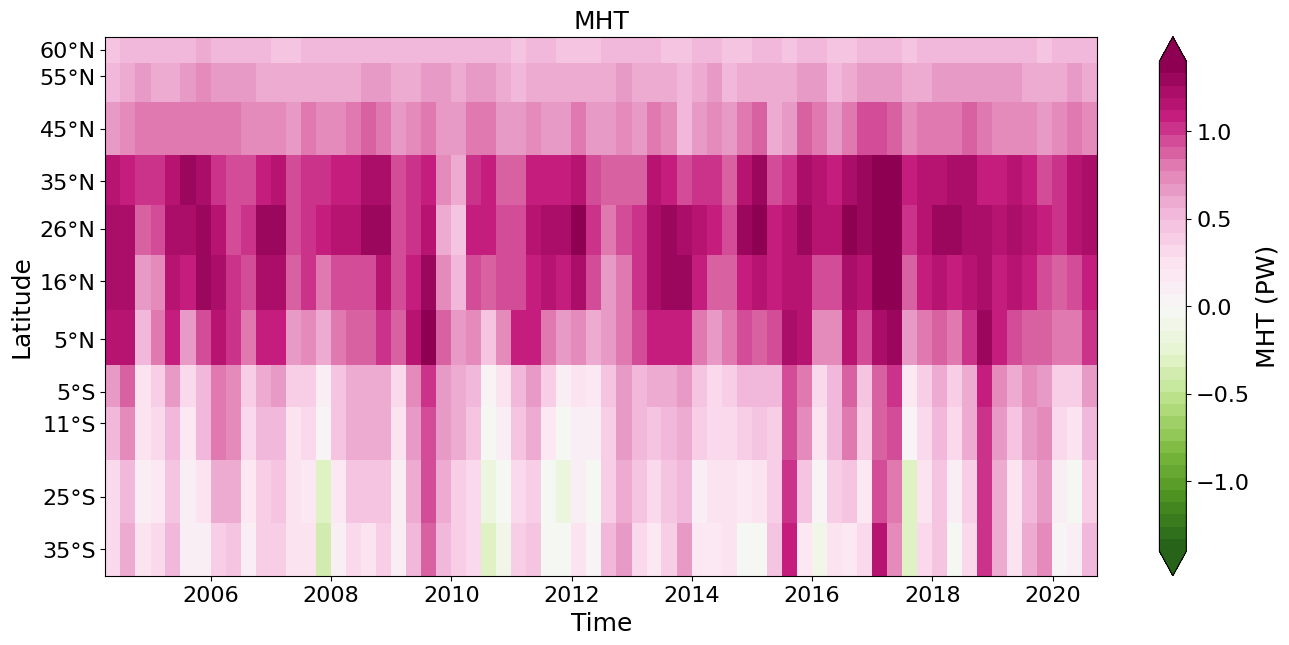

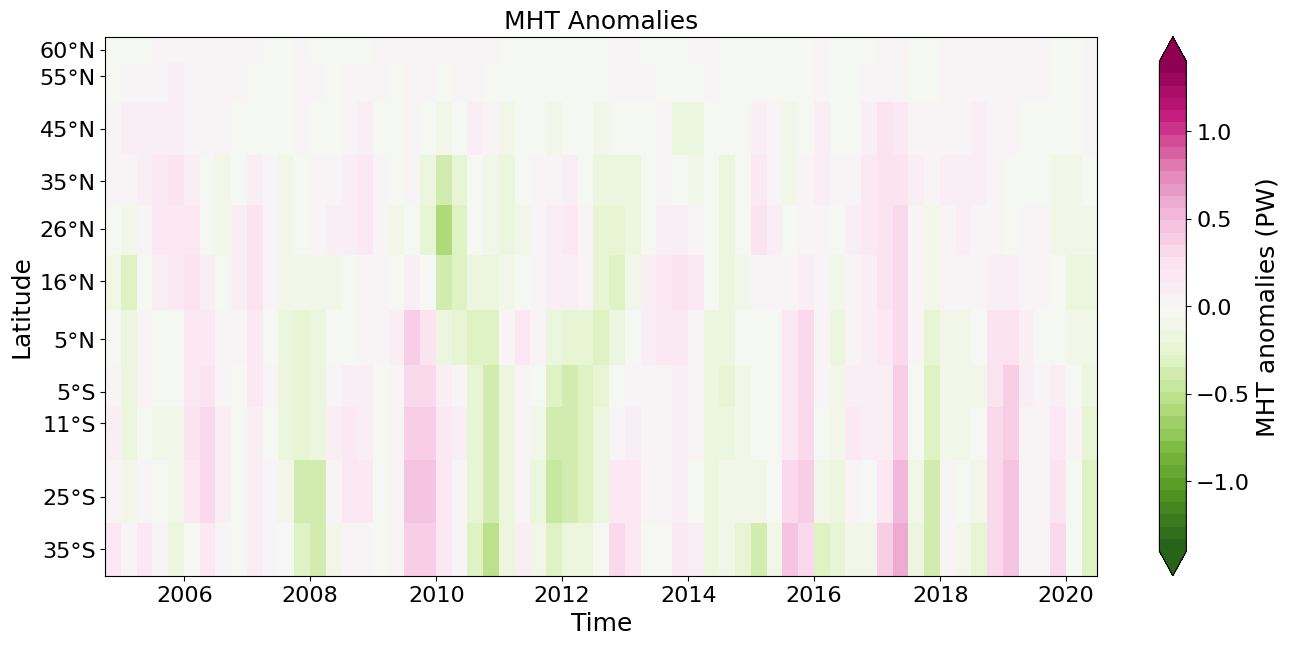

In [12]:
plot_hovmöller(
    mht_mean,
    lats=lats,
    lat_labels=lat_labels,
    anomalies=False,
    cmap=cmap_mht,
    vlimits=(-1.4, 1.4),
    savefig=True
)
plot_hovmöller(
    mht_filtered,
    lats=lats,
    lat_labels=lat_labels,
    anomalies=True,
    cmap=cmap_mht,
    savefig=True,
    vlimits=(-1.4, 1.4)
)


## cross correlation
## split year, before and after 

In [13]:
lats

array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])

In [14]:
# lat_block = (-25, 26)
lat_block = (-35, 35)


lat_min, lat_max = lat_block
mask = (lats >= lat_min) & (lats <= lat_max)
lat_idx = np.where(mask)[0]

periods = {
    "pre2009": ("2004", "2008-11"),
    "2009_2013": ("2009", "2013"),
    "post2013": ("2013", "2020"),
    "total": ("2004", "2020")
}



## cross corr gif

In [15]:


# dates = []
# for year in range(2008, 2020):
#     for month in ["02", "05", "08", "11"]:
#         dates.append(f"{year}-{month}-01")

# min_samples = 8  # skip frames where prior/later would be too small to be meaningful
# frames = []

# for date in dates:
#     ds_prior = mht_filtered.sel(time=slice(None, date))
#     ds_later = mht_filtered.sel(time=slice(date, None))

#     if ds_prior.sizes["time"] < min_samples or ds_later.sizes["time"] < min_samples:
#         continue

#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#     plot_crosscorr_gif(ds_prior, lats, lat_labels, significance=True, n_effs=n_effs_mht,
#                    title=f"Prior to {date} (n={ds_prior.sizes['time']})",
#                    cmap=cmap_corr, ax=axes[0])
#     plot_crosscorr_gif(ds_later, lats, lat_labels, significance=True, n_effs=n_effs_mht,
#                    title=f"After {date} (n={ds_later.sizes['time']})",
#                    cmap=cmap_corr, ax=axes[1])

#     fig.suptitle(date)
#     fig.tight_layout()

#     buf = io.BytesIO()
#     fig.savefig(buf, format="png", dpi=100)
#     buf.seek(0)
#     frames.append(Image.open(buf).copy())
#     plt.close(fig)

# frames[0].save(
#     "figures/cross_corr/gif/crosscorr_evolution.gif",
#     save_all=True,
#     append_images=frames[1:],
#     duration=500,
#     loop=0
# )

## split cross corelation into 3 periods

In [16]:
# ### adjust the n effs right now, since it still doenst work fully
# keys_to_change = lats
# n_effs_changed = n_effs_mht

# for key in keys_to_change:
#     n_effs_changed[key] = np.float64(50.0)

Period: pre2009, years: 2004-2008-11, samples: 19
Period: 2009_2013, years: 2009-2013, samples: 20
Period: post2013, years: 2013-2020, samples: 31
Period: total, years: 2004-2020, samples: 66
           mean_cross_coherence  n_valid_pairs  n_total_pairs
pre2009                0.621898            6.0           15.0
2009_2013                   NaN            1.0           15.0
post2013               0.619478            8.0           15.0
total                  0.532529            4.0           15.0


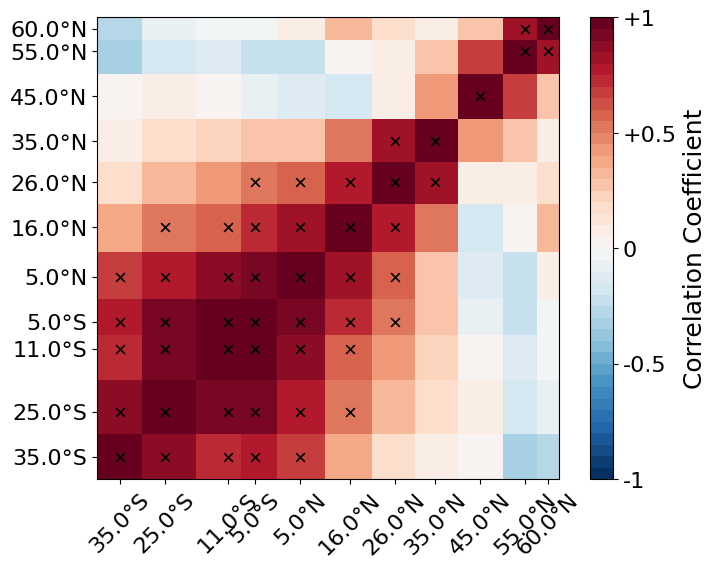

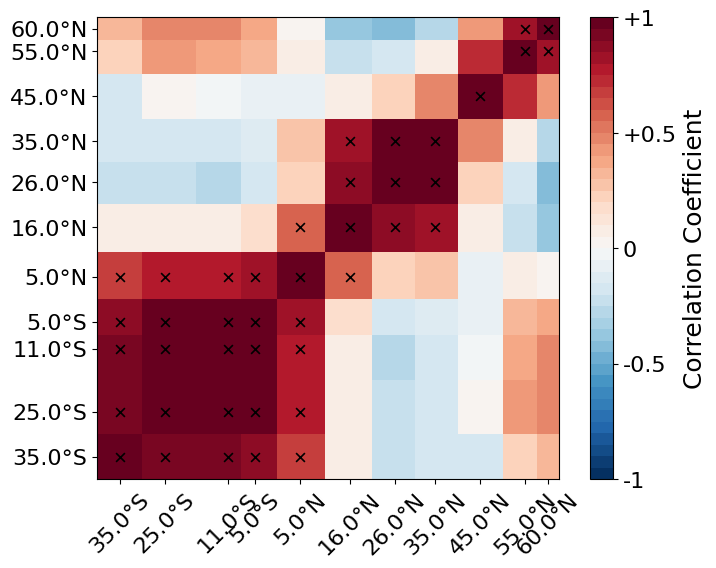

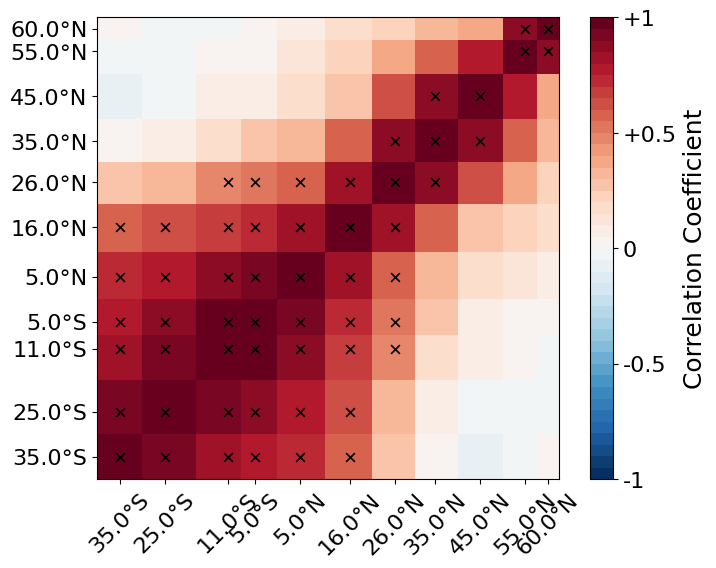

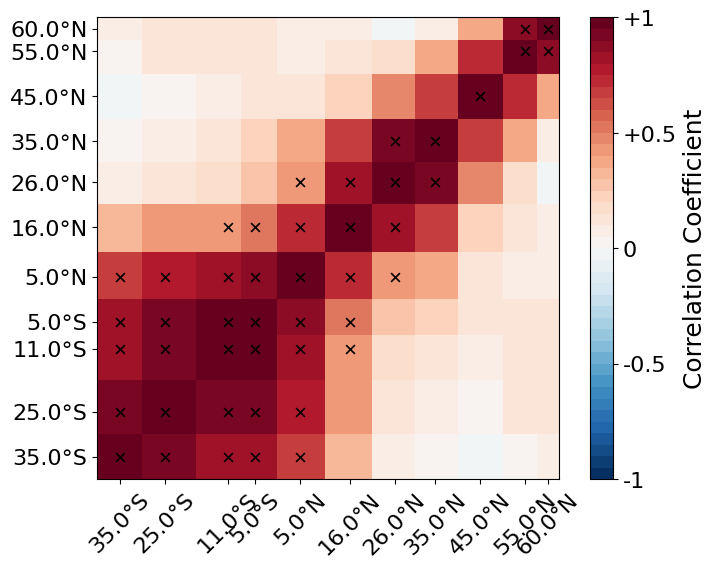

In [17]:

cmap_lats = cb.sequential.GnBu_9.mpl_colormap
lat_blocks = {
    "ST": (16, 35),
    "SA": (-35, 5),
    "coherence_block": (-35, 35)
}
## mask for both blocks
mask = (
    ((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1])) |
    ((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))
)
lat_idx = np.where(mask)[0]
lats_slice = lats[lat_idx]


# separate blocks
lat_min, lat_max = lat_blocks["ST"]
lats_st = lats[(lats >= lat_min) & (lats <= lat_max)]
st_positions = [np.where(lats == l)[0][0] for l in lats_st]

lat_min, lat_max = lat_blocks["SA"]
lats_sa = lats[(lats >= lat_min) & (lats <= lat_max)]
sa_positions = [np.where(lats == l)[0][0] for l in lats_sa]

periods_corrs = {}
periods_significance = {}
cross_block_results = {}

for period_name, (year_start, year_end) in periods.items():
    # data_period = mht_filtered.sel(time=slice(year_start, year_end))
    data_period = mht_mean.sel(time=slice(year_start, year_end))
    print(f"Period: {period_name}, years: {year_start}-{year_end}, samples: {data_period.sizes['time']}")
    # print("start of this period: ", data_period.time.values[0])
    # print("end of this period: ", data_period.time.values[-1])
    corr_matrix, significance_mask, _ = plot_crosscorr(
        data_period,
        lats=lats,
        lat_labels=lat_labels,
        cmap=cmap_corr,
        significance=True,
        n_effs=n_effs_mht, 
        title=f"Cross correlation of MHT ({period_name})",
        savefig=True,
        savename=f"crosscorr_mht_{period_name}"
    )
    
    periods_corrs[period_name] = corr_matrix
    periods_significance[period_name] = significance_mask

    # extract ST x SA cross-block sub-matrix straight from this period's matrix/mask
    cross_sub = corr_matrix[np.ix_(st_positions, sa_positions)]
    mask_sub = significance_mask[np.ix_(st_positions, sa_positions)]

    n_valid = int(mask_sub.sum())
    n_total = cross_sub.size
    mean_coh = cross_sub[mask_sub].mean() if n_valid >= 2 else np.nan

    cross_block_results[period_name] = {
        "mean_cross_coherence": mean_coh,
        "n_valid_pairs": n_valid,
        "n_total_pairs": n_total,
    }
    # print(corr_matrix)
cross_block_df = pd.DataFrame(cross_block_results).T
print(cross_block_df)


## timeseries

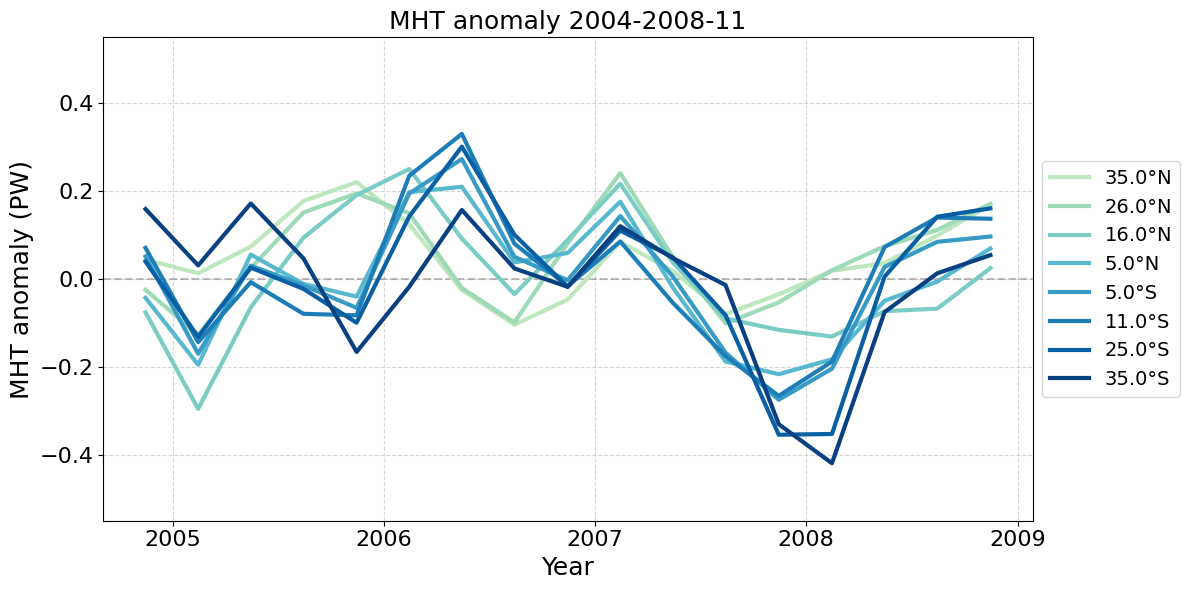

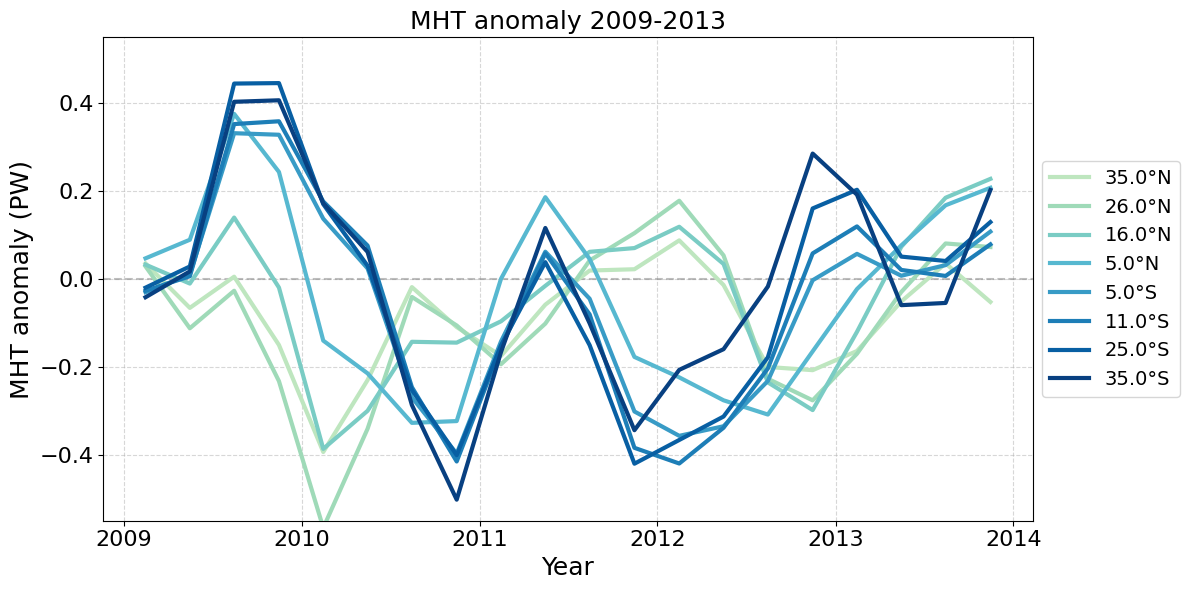

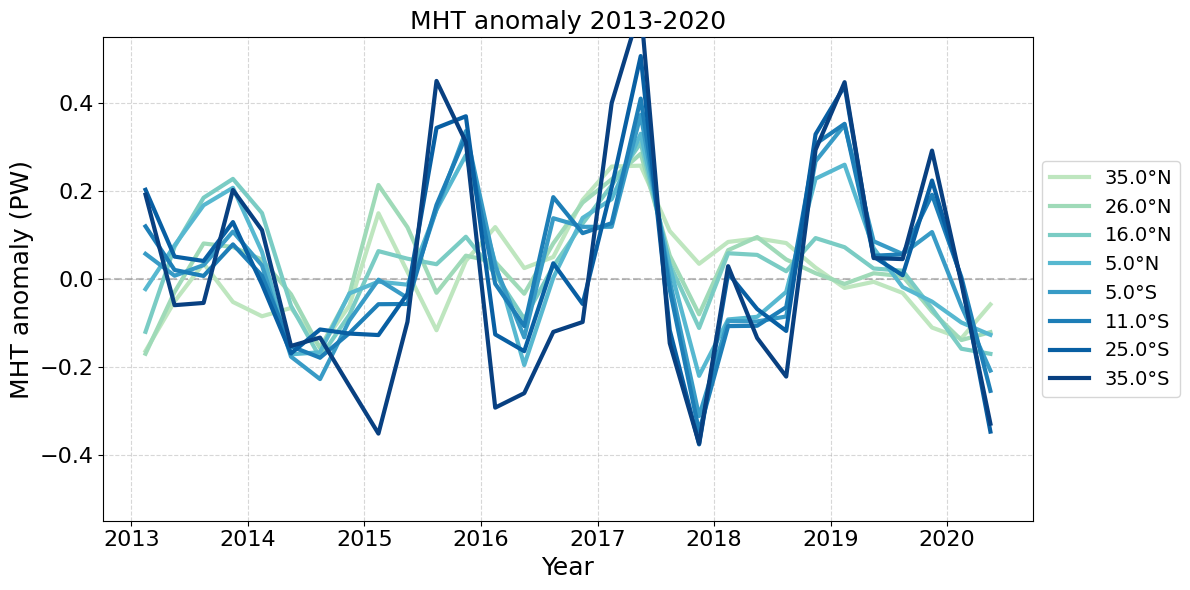

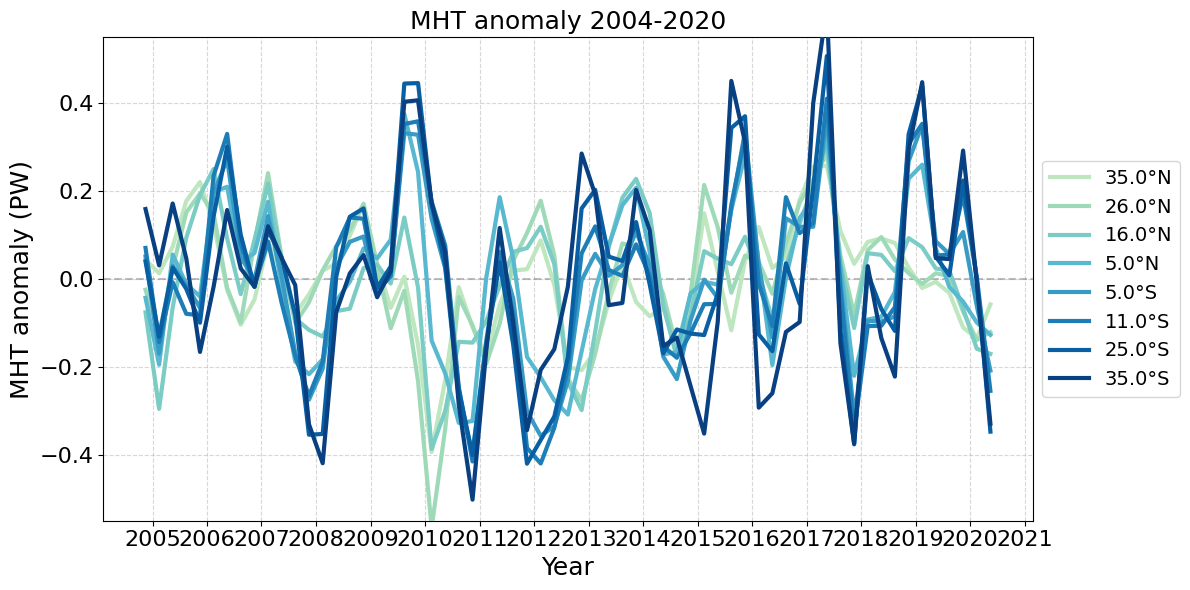

In [18]:

for period_name, (t0, t1) in periods.items():
    data_period = mht_filtered.sel(time=slice(t0, t1))  

    fig, ax = plot_timeseries(
        data=data_period,
        lats=lats_slice,        
        all_lats=lats,          
        labels=lat_labels,      
        title="MHT anomaly",
        savefig=True,
        savelabel=f"mht",
        label=f"{t0}-{t1}",
        grid=True,
        loc_legend=None,
        ylim=(-0.55, 0.55),
        cmap=cmap_lats
    )
    plt.show()

## timeseries of block means

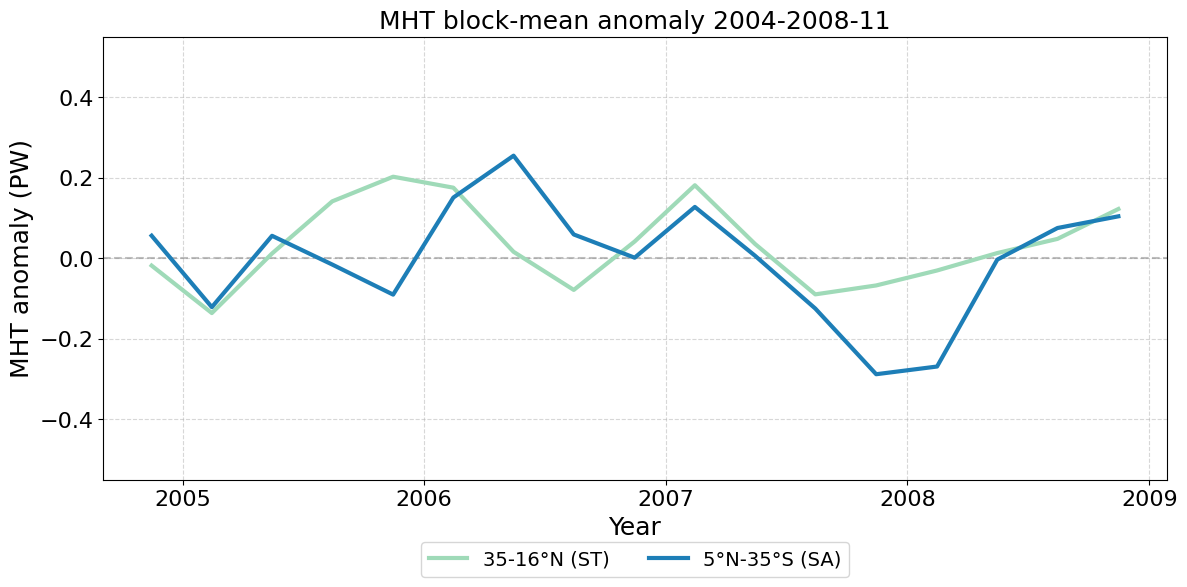

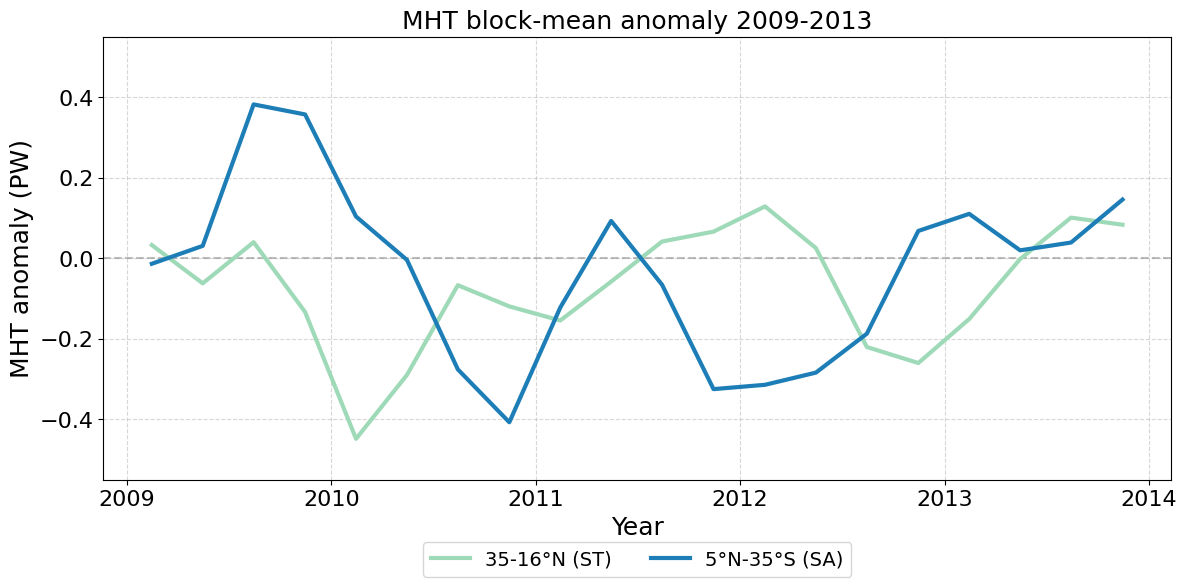

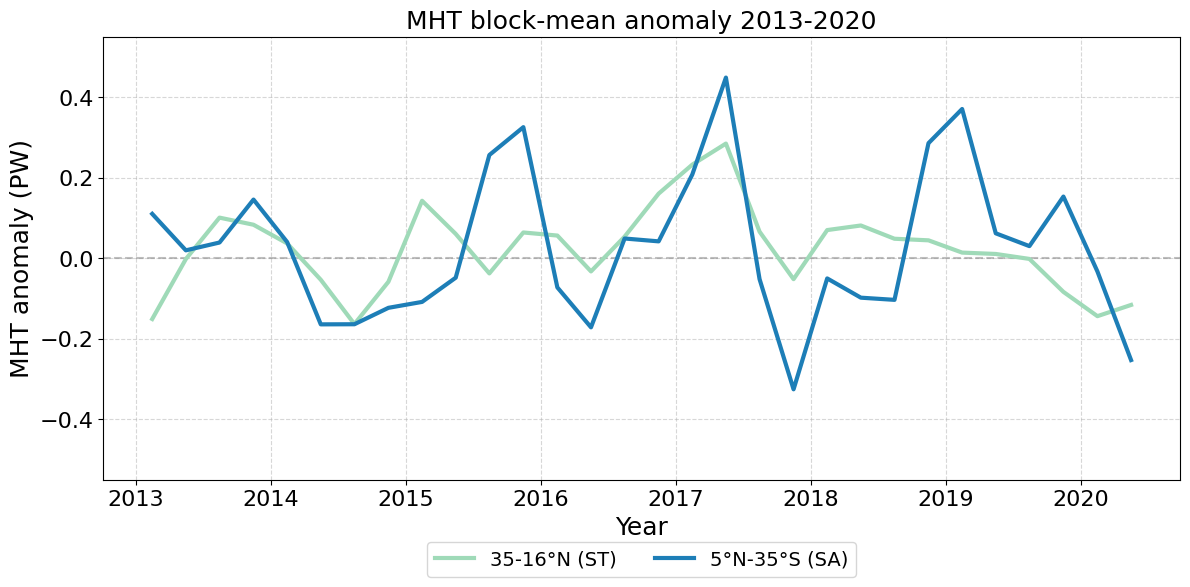

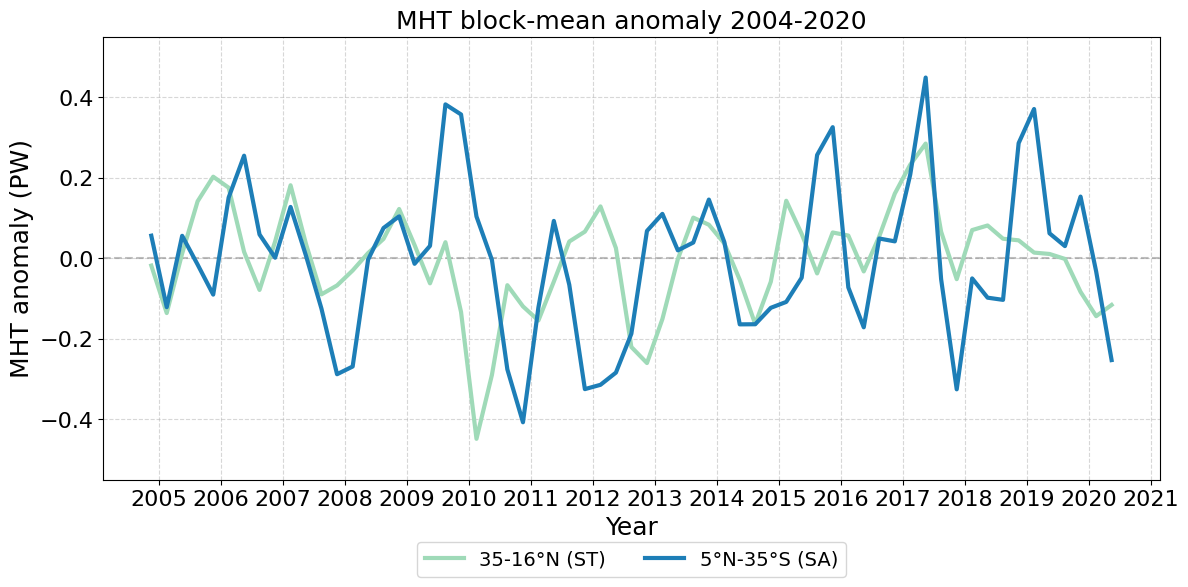

In [19]:


def crop_cmap(cmap, lo=0.3, hi=1.0, n=256):
    if hasattr(cmap, "mpl_colormap"):   # handles palettable objects too
        cmap = cmap.mpl_colormap
    colors = cmap(np.linspace(lo, hi, n))
    return mcolors.LinearSegmentedColormap.from_list(f"{getattr(cmap,'name','cmap')}_cropped", colors)

cmap_cropped_lats = crop_cmap(cb.sequential.GnBu_9, lo=0.4, hi=0.8)


for period_name, (t0, t1) in periods.items():
    period_data = mht_filtered.sel(time=slice(t0, t1))

    lat_min, lat_max = lat_blocks["ST"]
    mask = (lats >= lat_min) & (lats <= lat_max)
    lat_idx = np.where(mask)[0]
    st_mean = period_data.isel(lat=lat_idx).mean(dim="lat").expand_dims({"lat": [0]})

    lat_min, lat_max = lat_blocks["SA"]
    mask = (lats >= lat_min) & (lats <= lat_max)
    lat_idx = np.where(mask)[0]
    sa_mean = period_data.isel(lat=lat_idx).mean(dim="lat").expand_dims({"lat": [0]})

    data_blocks = {
        "35-16°N (ST)": st_mean,
        "5°N-35°S (SA)": sa_mean,
    }
    
    

    fig, ax = plot_timeseries(
        data=data_blocks,
        lats=[0],
        all_lats=[0],
        labels=["block mean"],
        title="MHT block-mean anomaly",
        cmap=cmap_cropped_lats,
        label=f"{t0}-{t1}",
        savefig=True,
        savelabel="MHT_blockmeans",
        grid=True,
        ylim=(-0.55, 0.55)
    )
    plt.show()

# check the z score between all for the 3 different timeperiods

In [20]:
# mht_zscore = (mht_filtered - mht_filtered.mean(dim="time")) / mht_filtered.std(dim="time", ddof=1)

## pairwise RMSE and correlation

## check pairwise correlation

# between blocks ST and SA

i dont do this anymore, as we discussed with eleanor that calcualting the significance like will never yield correlation high enough to be significance ( neff always too small for this short period) 
alwaays use the once pre calcuated neff to get r crit each time. 
cross check with the raw data if i still find the same or similar behavoir to check significance, or that we trust it


In [21]:
# summary = block_coherence_index(mht_filtered, r_crits_mht, lat_idx, lats, periods)
# # print(summary)

# lat_min, lat_max = lat_blocks["ST"]
# mask = (lats >= lat_min) & (lats <= lat_max)
# lat_idx = np.where(mask)[0]
# st_series = mht_filtered.isel(lat=lat_idx).mean(dim="lat")   # full time range, no lat dim left

# lat_min, lat_max = lat_blocks["SA"]
# mask = (lats >= lat_min) & (lats <= lat_max)
# lat_idx = np.where(mask)[0]
# sa_series = mht_filtered.isel(lat=lat_idx).mean(dim="lat")

# ## using the block mean for each block (so only time dim left)

# sig_df = between_block_significance(
#     st_series, sa_series,
#     periods,          
#     del_t=del_t,        # matching  compute_n_eff_and_r_crit 
#     time_unit=time_unit, 
#     plot=False 
# )
# print(sig_df)

## WITH THIS new n_eff for each period, do the cross correlation plot again with the correct significant markers!



In [22]:

# only_total = {k: v for k, v in periods.items() if k == "total"}

# sub_periods = {k: v for k, v in periods.items() if k != "total"}

# total = True 
# if total == True:
#     periods_sel = only_total
#     n = len(only_total)
# else: 
#     periods_sel = sub_periods
#     n = len(sub_periods)

# indiv_periods_significance = {}

# fig, axes = plt.subplots(1, len(periods_sel), figsize=(6.5 * n, 6), sharey=True)

# if n == 1:
#     axes = [axes]
    
# fig.subplots_adjust(right=0.9)  # leave some space for the colorbar on the right....
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]

# for i, (ax, (period_name, (t0, t1))) in enumerate(zip(axes, periods_sel.items())):
#     # period_data = mht_filtered_tukey.sel(time=slice(t0, t1))
#     period_data = mht_filtered.sel(time=slice(t0, t1))

#     print(f"Period: {period_name} ({t0}-{t1}), samples: {period_data.sizes['time']}")

#     ## get n eff etc for that period alone        
#     n_eff_period, r_crit_period, its_mht_period = compute_n_eff_and_r_crit(
#         period_data,
#         coord_values=lats,
#         coord_labels=lat_labels,
#         dim="lat",
#         del_t=del_t,
#         time_unit=time_unit,
#         plot=False
#     )
#     ## save the results
#     indiv_periods_significance[period_name] = {
#         "n_eff" : n_eff_period,
#         "r_crit": r_crit_period,
#         "its" : its_mht_period
#     }
#     ## plot cross correlation using neff for each period
    
#     corr_matrix, significance_mask, cf = plot_crosscorr(
#         period_data,
#         lats=lats,
#         lat_labels=lat_labels,
#         cmap=cmap_corr,
#         significance=True,
#         n_effs=n_eff_period,
#         subtitle=f"{period_name.replace("_", " ")}",
#         # savefig=True,
#         # savename=f"crosscorr_{period_name}",
#         ax=ax,
#         show_cbar=False # only last i has colorbar, or No one 
#         # savename=f"crosscorr_mht_{period_name}"
#     )

# cb = fig.colorbar(cf, cax=cbar_ax, label='Correlation Coefficient')
# cb.set_ticks([-1, -0.5, 0, 0.5, 1])

# fig.suptitle("Cross-Correlation of MHT anomalies per period")
# plt.tight_layout()
# plt.savefig("figures/cross_corr/crosscorr_all", dpi=300, bbox_inches='tight')
    

In [23]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 20,
    'axes.labelsize'  : 20,
    # ticks
    'xtick.labelsize' : 18,
    'ytick.labelsize' : 18,
    
    # legend
    'legend.fontsize' : 18,
    'legend.title_fontsize': 18,
    # colorbar
    'figure.titlesize': 22,
})



## ideas to quantify coherence break with heat and timescales

## maybe calculate an annual mean of MHT inside the block, for boths smaller blocks for the 3 periods
## and plot timeseries of it or so? 
## also not anomalies but values of MHT  ? 

In [24]:
mht_mean_filtered = process_data(mht_mean, restore_mean=True)

lat_idx_st = np.where((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1]))[0]
lat_idx_sa = np.where((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))[0]


st_data = mht_filtered.isel(lat=lat_idx_st)#.mean(dim="lat")
sa_data = mht_filtered.isel(lat=lat_idx_sa)#.mean(dim="lat")

blocks_dict = {
    "ST": st_data,
    "SA": sa_data
}

In [25]:

##################
#  1. AMPLITUDE  #
##################

def block_amplitude(blocks_dict, periods):
    """
    calculated the amplitude (std and peak-to-peak) of the time series for each block and period.
    Amplitude is temporal STD of block
    series_dict: {'ST': st_series, 'SA': sa_series}
    """
    rows = {}
    for block_name, block_data in blocks_dict.items():
        block_mean = block_data.mean(dim="lat")
        # block is ST and SA
        for period_name, (t0, t1) in periods.items():
            s = block_mean.sel(time=slice(t0, t1))
            
            rows[(block_name, period_name)] = {
                "std": float(s.std(dim="time")),
                "peak_to_peak": float(s.max() - s.min()),
            }
    return pd.DataFrame(rows).T

amp_df = block_amplitude(blocks_dict, periods)
# print("Amplitu#de DataFrame:\n", amp_df)
# print("SA/ST amplitude ratio:\n", amp_df.xs("SA", level=0)["std"] / amp_df.xs("ST", level=0)["std"])

##################
#  2. spatial spread #
##################

def spatial_spread(blocks_dict, periods):
    """
     latitudinal STD over block, averaged over time for each period.
    """
    rows = {}
    for block_name, block_data in blocks_dict.items():        
        for period_name, (t0, t1) in periods.items():
            s = block_data.sel(time=slice(t0, t1)).std(dim="lat").mean()
            rows[(block_name, period_name)] = float(s)
    return pd.Series(rows)

spread = spatial_spread(blocks_dict, periods)
print("spatial spread:\n", spread)

##########################################
#  spread across both blocks combined    #
##########################################

lat_idx_across = np.where(
    ((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1])) |
    ((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))
)[0]

across_data = mht_filtered.isel(lat=lat_idx_across)

def spread_across_blocks(block_data, periods):
    """
    Latitudinal STD pooling both ST and SA latitudes together,
    averaged over time for each period. Answers: how spread out
    is the anomaly across the whole ST+SA latitude range, treating
    it as one combined set of latitudes (not two separate blocks).
    """
    rows = {}
    for period_name, (t0, t1) in periods.items():
        s = block_data.sel(time=slice(t0, t1)).std(dim="lat").mean()
        rows[period_name] = float(s)
    return pd.Series(rows)

across_spread = spread_across_blocks(across_data, periods)
print("spread across both blocks combined:\n", across_spread)

# avg_individual = (spread["ST"] + spread["SA"]) / 2 # average across spead 
# excess_spread = across_spread - avg_individual

# print("average individual spread:\n", avg_individual)
# print("excess spread (across - average individual):\n", excess_spread)

spatial spread:
 ST  pre2009      0.052409
    2009_2013    0.045321
    post2013     0.036526
    total        0.041897
SA  pre2009      0.055131
    2009_2013    0.070224
    post2013     0.065715
    total        0.064416
dtype: float64
spread across both blocks combined:
 pre2009      0.081393
2009_2013    0.133192
post2013     0.094772
total        0.103725
dtype: float64


In [26]:
# lat_sel = 26
# fig, ax = plot_timeseries(
#     data={
#         "mean filtered": mht_mean_filtered,
#         "anomalies filtered": mht_filtered,
#         "raw": mht_mean,
#     },
#     lats=[lat_sel],          # single latitude, still needs to be a list/array
#     all_lats=lats,    # same full lat list you always pass, for color lookup
#     labels=lat_labels,
#     title="MHT",
#     label=f"{lat_sel}°N",
#     anomalies=False,
#     cmap=plt.cm.Dark2,
# )

In [27]:
# for lat in lats:
#     print(lat, r_crits_mht[lat], critical_r(n_effs_mht[lat]))

In [28]:
lat_idx_na = np.where((lats >= lat_blocks["ST"][0]) & (lats <= lat_blocks["ST"][1]))[0]
lat_idx_sa = np.where((lats >= lat_blocks["SA"][0]) & (lats <= lat_blocks["SA"][1]))[0]

cross_result = cross_block_coherence_index(
    mht_mean_filtered, r_crits_mht, lat_idx_na, lat_idx_sa, lats, periods
)
print(cross_result)


           within_A_coherence  within_A_n_valid  within_A_n_total  \
pre2009              0.777902               2.0               3.0   
2009_2013            0.897320               3.0               3.0   
post2013             0.854871               2.0               3.0   
total                0.867083               2.0               3.0   

           within_B_coherence  within_B_n_valid  within_B_n_total  \
pre2009              0.820450              10.0              10.0   
2009_2013            0.862334              10.0              10.0   
post2013             0.872694              10.0              10.0   
total                0.857323              10.0              10.0   

           cross_AB_coherence  cross_AB_n_valid  cross_AB_n_total  
pre2009              0.553543               6.0              15.0  
2009_2013            0.060019               2.0              15.0  
post2013             0.584384               7.0              15.0  
total                0.551319       

In [29]:
# amp_na = block_mean_amplitude(mht_mean_filtered, lat_idx_na, lats, periods)
# amp_sa = block_mean_amplitude(mht_mean_filtered, lat_idx_sa, lats, periods)

# print("NA/ST block amplitude:\n", amp_na)
# print("SA block amplitude:\n", amp_sa)

# lead lag stuff

/Users/leadietz/Desktop/uni/masterthesis/coding/stats_plots.py:1496: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


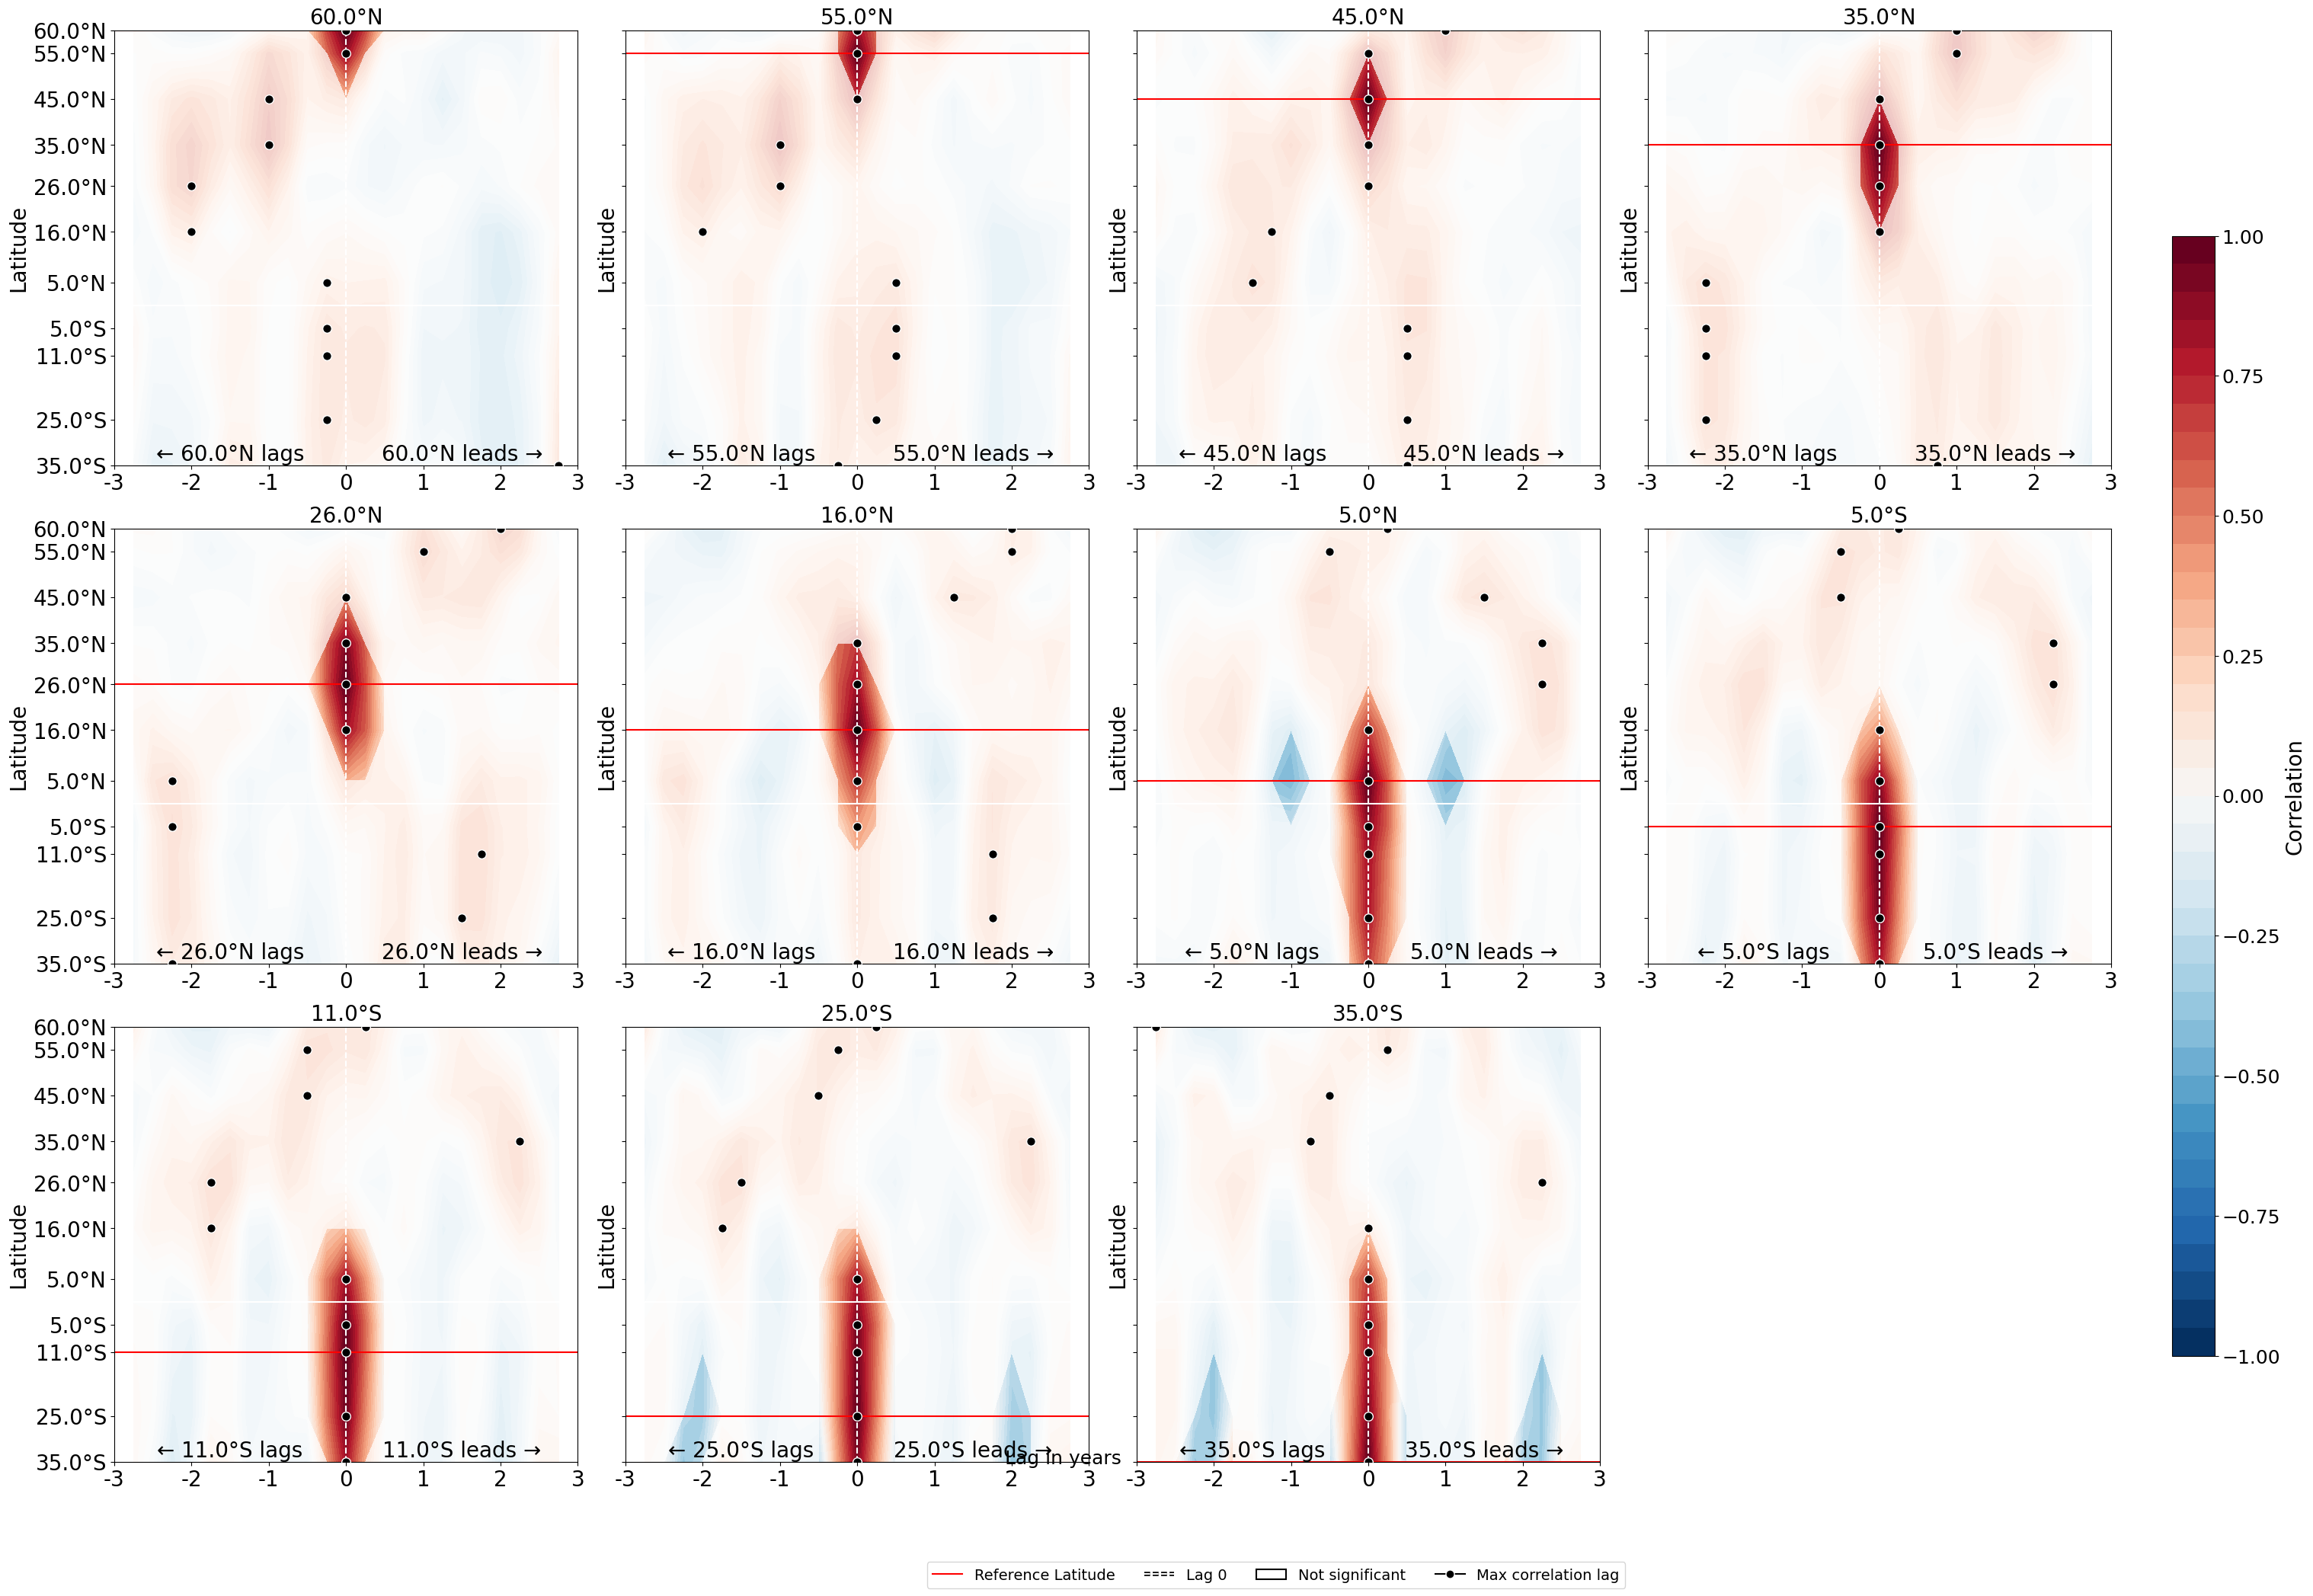

In [30]:
nlags = 12
all_lags = np.arange(-(nlags-1), nlags)
# all_lags = np.arange(0, nlags + 1)
lag_units = time_unit

_ = plot_all_leadlag(
    data=mht_filtered,
    lats=lats,
    lat_labels=lat_labels,
    #lats=[26],
    #lat_labels=["26.0°N"],
    all_lats=lats,
    all_lat_labels=lat_labels,
    nlags=nlags,
    all_lags=all_lags,
    ncols=4,
    significance=True,
    n_effs=n_effs_mht,
    cmap=cmap_corr,
    savefig=True,
    savename="mht_leadlag_26N"
)

In [31]:
# nlags = 12
# all_lags = np.arange(-(nlags-1), nlags)
# # all_lags = np.arange(0, nlags + 1)
# lag_units = time_unit

# _ = plot_all_leadlag(
#     mht_filtered, lats, lat_labels,
#     nlags, all_lags, lag_units=lag_units,
#     significance=True, n_effs=n_effs_mht,
#     cmap=cmap_corr,
#     savefig=True
# )

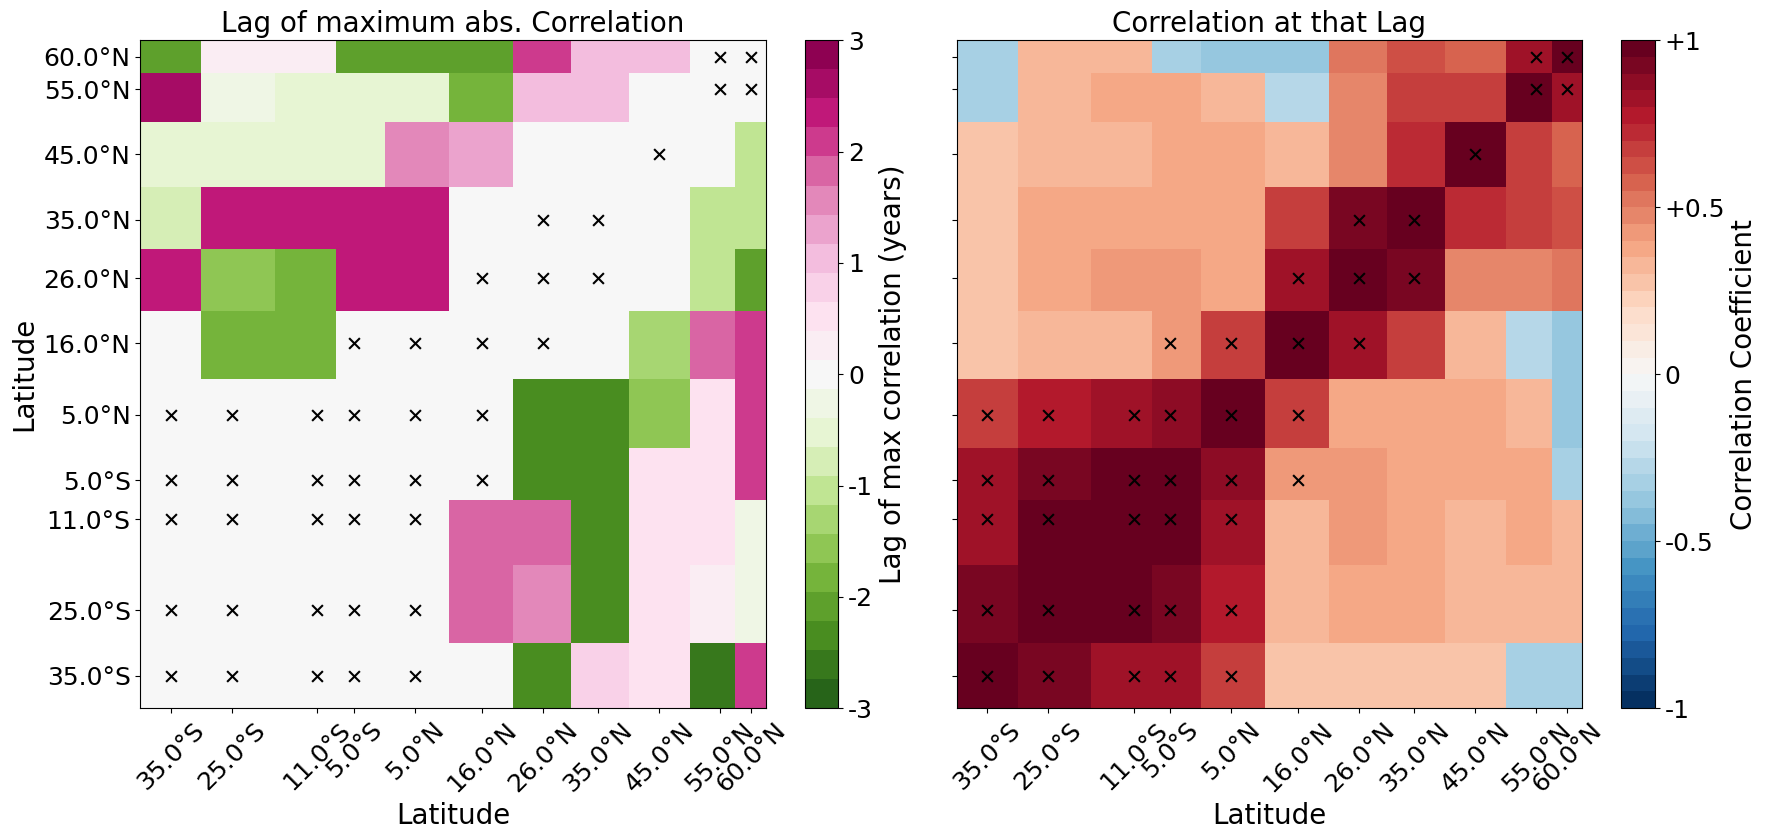

In [32]:


_ = plot_max_lag(mht_filtered,
                     lats, lat_labels, 
                     nlags, all_lags, lag_units=lag_units, 
                     significance=True, n_effs=n_effs_mht,
                     title="Lag of Maximum Correlation for MHT", 
                     cmap_corr=cmap_corr,
                     cmap_lag=cmap_maxlag,
                     savefig=True)

## lead lag only between block means

In [33]:
# n_effs_st = {key:val for key, val in n_effs_mht.items() if key in [35, 26, 16]}
# n_eff_st = min(n_effs_st.values())
# # print(n_eff_st)
# n_effs_sa = {key:val for key, val in n_effs_mht.items() if key in [-35, -25, -11, -5, 5]}
# n_eff_sa = min(n_effs_sa.values())
# # print(n_eff_sa)

# nlags=8
# all_lags = np.arange(-(nlags-1), nlags)

# _ = block_leadlag(st_data.mean(dim="lat"), sa_data.mean(dim="lat"),
#               periods,
#               nlags=nlags,
#               all_lags=all_lags,
#               n_eff_sa=n_eff_sa,
#               n_eff_st=n_eff_st
# )